#### remember taker vs maker strat

we need to pick, size of our trades, entry/exit signal, leverage (borrowing money)

In [46]:
import polars as pl
import numpy as np
from datetime import datetime, timedelta
import random

import torch
import torch.nn as nn
import torch.optim as optim
import research

import altair as alt

import binance

In [47]:
import models
# TODO: retrain model with 3 features
model = models.LinearModel(1)

model.load_state_dict(torch.load('model_weights.pth', weights_only=True))
model.eval()

LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

### Model Params

In [48]:
research.print_model_params(model)

linear.weight:
[[-0.04923647]]
linear.bias:
[0.00027393]


### Mean Reversion

In [49]:
series = [-0.014, 0.011399, -0.012212, 0.01997, -0.01442, 0.01227]
mu = np.mean(series)
mean_reversion_df = pl.DataFrame({'log_return': series, 'mean': mu})
mean_reversion_df

log_return,mean
f64,f64
-0.014,0.000501
0.011399,0.000501
-0.012212,0.000501
0.01997,0.000501
-0.01442,0.000501
0.01227,0.000501


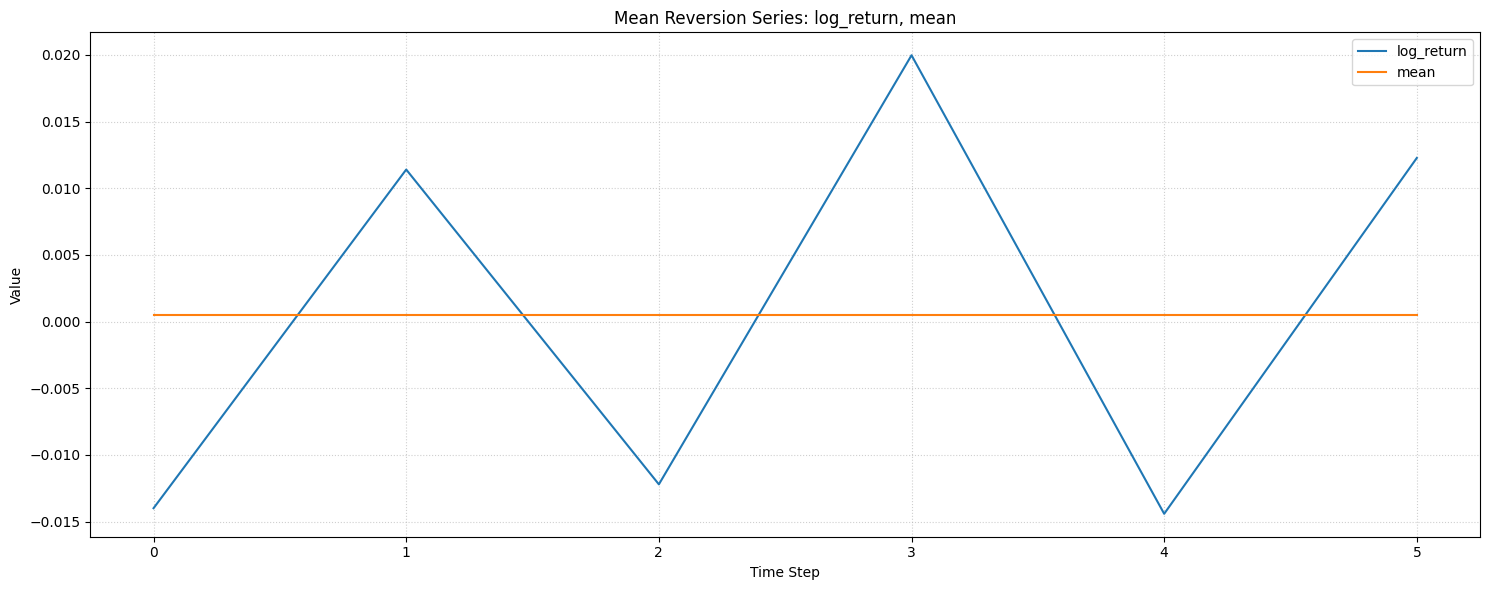

In [50]:
research.plot_multiple_lines(mean_reversion_df, ['log_return', 'mean'], 'Mean Reversion')

## Strategy development

### load time series

In [51]:
sym = 'BTCUSDT'
time_interval='8h'

ts = pl.read_csv(f"{sym}_{time_interval}_ohlc.csv", try_parse_dates=True).sort('datetime')
ts

datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71004.2
2024-10-29 08:00:00,71004.1,72490.0,70900.0,72374.9
2024-10-29 16:00:00,72374.9,73660.0,71871.1,72739.5
2024-10-30 00:00:00,72739.5,72797.4,72018.0,72244.8
2024-10-30 08:00:00,72244.8,72620.0,71444.2,72058.8
…,…,…,…,…
2025-11-29 08:00:00,90523.4,91068.1,90335.2,91030.0
2025-11-29 16:00:00,91030.0,91130.0,90092.7,90765.0
2026-04-25 00:00:00,77395.3,77678.0,77254.7,77449.9


#### add target and features


In [52]:
forecast_horizon = 1
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=3)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71004.2,null,null,null,null
2024-10-29 08:00:00,71004.1,72490.0,70900.0,72374.9,0.019121,null,null,null
2024-10-29 16:00:00,72374.9,73660.0,71871.1,72739.5,0.005025,0.019121,null,null
2024-10-30 00:00:00,72739.5,72797.4,72018.0,72244.8,-0.006824,0.005025,0.019121,null
2024-10-30 08:00:00,72244.8,72620.0,71444.2,72058.8,-0.002578,-0.006824,0.005025,0.019121
…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91068.1,90335.2,91030.0,0.00558,-0.294957,0.00412,-0.006327
2025-11-29 16:00:00,91030.0,91130.0,90092.7,90765.0,-0.002915,0.00558,-0.294957,0.00412
2026-04-25 00:00:00,77395.3,77678.0,77254.7,77449.9,-0.158642,-0.002915,0.00558,-0.294957


In [53]:
test_size = 0.25
_, trades = research.timeseries_split(ts, test_size)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2025-07-17 00:00:00,118590.7,119151.3,117663.6,118293.9,-0.002506,-0.003916,0.007375,0.003753
2025-07-17 08:00:00,118293.8,119216.4,117412.8,118875.0,0.0049,-0.002506,-0.003916,0.007375
2025-07-17 16:00:00,118875.0,120951.5,118293.6,119176.6,0.002534,0.0049,-0.002506,-0.003916
2025-07-18 00:00:00,119176.5,120846.1,119003.8,119356.6,0.001509,0.002534,0.0049,-0.002506
2025-07-18 08:00:00,119356.5,119519.8,117230.7,117830.0,-0.012873,0.001509,0.002534,0.0049
…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91068.1,90335.2,91030.0,0.00558,-0.294957,0.00412,-0.006327
2025-11-29 16:00:00,91030.0,91130.0,90092.7,90765.0,-0.002915,0.00558,-0.294957,0.00412
2026-04-25 00:00:00,77395.3,77678.0,77254.7,77449.9,-0.158642,-0.002915,0.00558,-0.294957


#### strategy decision #1, entry/exit signal

In [54]:
# 1. time based. exit 8 hours later
# 2. predicate based. prediction, but until certain condition is satisfied, make prediction



##### add model predictions

In [55]:
target = 'close_log_return'
features = [f'{target}_lag_1']
trades = research.add_model_predictions(trades, model, features)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32
2025-07-17 00:00:00,118590.7,119151.3,117663.6,118293.9,-0.002506,-0.003916,0.007375,0.003753,0.000467
2025-07-17 08:00:00,118293.8,119216.4,117412.8,118875.0,0.0049,-0.002506,-0.003916,0.007375,0.000397
2025-07-17 16:00:00,118875.0,120951.5,118293.6,119176.6,0.002534,0.0049,-0.002506,-0.003916,0.000033
2025-07-18 00:00:00,119176.5,120846.1,119003.8,119356.6,0.001509,0.002534,0.0049,-0.002506,0.000149
2025-07-18 08:00:00,119356.5,119519.8,117230.7,117830.0,-0.012873,0.001509,0.002534,0.0049,0.0002
…,…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91068.1,90335.2,91030.0,0.00558,-0.294957,0.00412,-0.006327,0.014797
2025-11-29 16:00:00,91030.0,91130.0,90092.7,90765.0,-0.002915,0.00558,-0.294957,0.00412,-7.9431e-7
2026-04-25 00:00:00,77395.3,77678.0,77254.7,77449.9,-0.158642,-0.002915,0.00558,-0.294957,0.000417


##### add directional signal

In [56]:
trades = trades.with_columns(pl.col('y_hat').sign().alias('dir_signal'))
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32
2025-07-17 00:00:00,118590.7,119151.3,117663.6,118293.9,-0.002506,-0.003916,0.007375,0.003753,0.000467,1.0
2025-07-17 08:00:00,118293.8,119216.4,117412.8,118875.0,0.0049,-0.002506,-0.003916,0.007375,0.000397,1.0
2025-07-17 16:00:00,118875.0,120951.5,118293.6,119176.6,0.002534,0.0049,-0.002506,-0.003916,0.000033,1.0
2025-07-18 00:00:00,119176.5,120846.1,119003.8,119356.6,0.001509,0.002534,0.0049,-0.002506,0.000149,1.0
2025-07-18 08:00:00,119356.5,119519.8,117230.7,117830.0,-0.012873,0.001509,0.002534,0.0049,0.0002,1.0
…,…,…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91068.1,90335.2,91030.0,0.00558,-0.294957,0.00412,-0.006327,0.014797,1.0
2025-11-29 16:00:00,91030.0,91130.0,90092.7,90765.0,-0.002915,0.00558,-0.294957,0.00412,-7.9431e-7,-1.0
2026-04-25 00:00:00,77395.3,77678.0,77254.7,77449.9,-0.158642,-0.002915,0.00558,-0.294957,0.000417,1.0


#### calc trade log return

In [57]:
trades= trades.with_columns(
    (pl.col('close_log_return') * pl.col('dir_signal')).alias('trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64
2025-07-17 00:00:00,118590.7,119151.3,117663.6,118293.9,-0.002506,-0.003916,0.007375,0.003753,0.000467,1.0,-0.002506
2025-07-17 08:00:00,118293.8,119216.4,117412.8,118875.0,0.0049,-0.002506,-0.003916,0.007375,0.000397,1.0,0.0049
2025-07-17 16:00:00,118875.0,120951.5,118293.6,119176.6,0.002534,0.0049,-0.002506,-0.003916,0.000033,1.0,0.002534
2025-07-18 00:00:00,119176.5,120846.1,119003.8,119356.6,0.001509,0.002534,0.0049,-0.002506,0.000149,1.0,0.001509
2025-07-18 08:00:00,119356.5,119519.8,117230.7,117830.0,-0.012873,0.001509,0.002534,0.0049,0.0002,1.0,-0.012873
…,…,…,…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91068.1,90335.2,91030.0,0.00558,-0.294957,0.00412,-0.006327,0.014797,1.0,0.00558
2025-11-29 16:00:00,91030.0,91130.0,90092.7,90765.0,-0.002915,0.00558,-0.294957,0.00412,-7.9431e-7,-1.0,0.002915
2026-04-25 00:00:00,77395.3,77678.0,77254.7,77449.9,-0.158642,-0.002915,0.00558,-0.294957,0.000417,1.0,-0.158642


#### calc cumulative trade log return

In [58]:
trades = trades.with_columns(
    pl.col('trade_log_return').cum_sum().alias('cum_trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64
2025-07-17 00:00:00,118590.7,119151.3,117663.6,118293.9,-0.002506,-0.003916,0.007375,0.003753,0.000467,1.0,-0.002506,-0.002506
2025-07-17 08:00:00,118293.8,119216.4,117412.8,118875.0,0.0049,-0.002506,-0.003916,0.007375,0.000397,1.0,0.0049,0.002394
2025-07-17 16:00:00,118875.0,120951.5,118293.6,119176.6,0.002534,0.0049,-0.002506,-0.003916,0.000033,1.0,0.002534,0.004928
2025-07-18 00:00:00,119176.5,120846.1,119003.8,119356.6,0.001509,0.002534,0.0049,-0.002506,0.000149,1.0,0.001509,0.006438
2025-07-18 08:00:00,119356.5,119519.8,117230.7,117830.0,-0.012873,0.001509,0.002534,0.0049,0.0002,1.0,-0.012873,-0.006435
…,…,…,…,…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91068.1,90335.2,91030.0,0.00558,-0.294957,0.00412,-0.006327,0.014797,1.0,0.00558,-0.005979
2025-11-29 16:00:00,91030.0,91130.0,90092.7,90765.0,-0.002915,0.00558,-0.294957,0.00412,-7.9431e-7,-1.0,0.002915,-0.003064
2026-04-25 00:00:00,77395.3,77678.0,77254.7,77449.9,-0.158642,-0.002915,0.00558,-0.294957,0.000417,1.0,-0.158642,-0.161706


#### display equity curve (log space)

In [59]:
research.plot_column(trades, 'cum_trade_log_return')

alt.Chart(...)

## Strategy decision #2: Trade sizing

In [60]:
#1. constant trade size
#2. compounding trade size

##### constant sizing

In [61]:
capital = 100
ratio = 1.0
trade_value = ratio * capital

# entry trade value and exit trade value
trades = trades.with_columns(
    pl.lit(trade_value).alias('entry_trade_value'),
    (trade_value * pl.col('trade_log_return').exp()).alias('exit_trade_value'),
    (trade_value / pl.col('open')).alias('trade_qty'),
).with_columns(
    (pl.col('trade_qty') * pl.col('dir_signal')).alias('signed_trade_qty')
)
trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty
datetime[μs],f64,f64,f64,f32,f64,f64,f64
2025-07-17 00:00:00,118590.7,118293.9,-0.002506,0.000467,100.0,99.749727,0.000843
2025-07-17 08:00:00,118293.8,118875.0,0.0049,0.000397,100.0,100.491234,0.000845
2025-07-17 16:00:00,118875.0,119176.6,0.002534,0.000033,100.0,100.253712,0.000841
2025-07-18 00:00:00,119176.5,119356.6,0.001509,0.000149,100.0,100.151036,0.000839
2025-07-18 08:00:00,119356.5,117830.0,-0.012873,0.0002,100.0,98.720976,0.000838
…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91030.0,0.00558,0.014797,100.0,100.559523,0.001105
2025-11-29 16:00:00,91030.0,90765.0,0.002915,-7.9431e-7,100.0,100.291963,-0.001099
2026-04-25 00:00:00,77395.3,77449.9,-0.158642,0.000417,100.0,85.330138,0.001292


#### add trade gross profit and loss

In [62]:
trades = trades.with_columns(
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl')
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64
2025-07-17 00:00:00,118590.7,118293.9,-0.002506,0.000467,100.0,99.749727,0.000843,-0.250273
2025-07-17 08:00:00,118293.8,118875.0,0.0049,0.000397,100.0,100.491234,0.000845,0.491234
2025-07-17 16:00:00,118875.0,119176.6,0.002534,0.000033,100.0,100.253712,0.000841,0.253712
2025-07-18 00:00:00,119176.5,119356.6,0.001509,0.000149,100.0,100.151036,0.000839,0.151036
2025-07-18 08:00:00,119356.5,117830.0,-0.012873,0.0002,100.0,98.720976,0.000838,-1.279024
…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91030.0,0.00558,0.014797,100.0,100.559523,0.001105,0.559523
2025-11-29 16:00:00,91030.0,90765.0,0.002915,-7.9431e-7,100.0,100.291963,-0.001099,0.291963
2026-04-25 00:00:00,77395.3,77449.9,-0.158642,0.000417,100.0,85.330138,0.001292,-14.669862


#### Add transaction fees 

In [63]:
taker_fee = binance.TAKER_FEE
maker_fee = binance.MAKER_FEE

trades = trades.with_columns(
    (pl.col('entry_trade_value') * taker_fee + pl.col('exit_trade_value') * taker_fee).alias('taker_fee'),
    (pl.col('entry_trade_value') * maker_fee + pl.col('exit_trade_value') * maker_fee).alias('maker_fee')
)


trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl', 'maker_fee', 'taker_fee')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,maker_fee,taker_fee
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2025-07-17 00:00:00,118590.7,118293.9,-0.002506,0.000467,100.0,99.749727,0.000843,-0.250273,0.089887,0.089887
2025-07-17 08:00:00,118293.8,118875.0,0.0049,0.000397,100.0,100.491234,0.000845,0.491234,0.090221,0.090221
2025-07-17 16:00:00,118875.0,119176.6,0.002534,0.000033,100.0,100.253712,0.000841,0.253712,0.090114,0.090114
2025-07-18 00:00:00,119176.5,119356.6,0.001509,0.000149,100.0,100.151036,0.000839,0.151036,0.090068,0.090068
2025-07-18 08:00:00,119356.5,117830.0,-0.012873,0.0002,100.0,98.720976,0.000838,-1.279024,0.089424,0.089424
…,…,…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91030.0,0.00558,0.014797,100.0,100.559523,0.001105,0.559523,0.090252,0.090252
2025-11-29 16:00:00,91030.0,90765.0,0.002915,-7.9431e-7,100.0,100.291963,-0.001099,0.291963,0.090131,0.090131
2026-04-25 00:00:00,77395.3,77449.9,-0.158642,0.000417,100.0,85.330138,0.001292,-14.669862,0.083399,0.083399


##### calc net trade pnl

In [64]:
trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('maker_fee')).alias('trade_net_maker_pnl'),
    (pl.col('trade_gross_pnl') - pl.col('taker_fee')).alias('trade_net_taker_pnl'),
)


trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl', 'trade_net_taker_pnl', 'trade_net_maker_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,trade_net_taker_pnl,trade_net_maker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2025-07-17 00:00:00,118590.7,118293.9,-0.002506,0.000467,100.0,99.749727,0.000843,-0.250273,-0.34016,-0.34016
2025-07-17 08:00:00,118293.8,118875.0,0.0049,0.000397,100.0,100.491234,0.000845,0.491234,0.401013,0.401013
2025-07-17 16:00:00,118875.0,119176.6,0.002534,0.000033,100.0,100.253712,0.000841,0.253712,0.163598,0.163598
2025-07-18 00:00:00,119176.5,119356.6,0.001509,0.000149,100.0,100.151036,0.000839,0.151036,0.060968,0.060968
2025-07-18 08:00:00,119356.5,117830.0,-0.012873,0.0002,100.0,98.720976,0.000838,-1.279024,-1.368449,-1.368449
…,…,…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91030.0,0.00558,0.014797,100.0,100.559523,0.001105,0.559523,0.469271,0.469271
2025-11-29 16:00:00,91030.0,90765.0,0.002915,-7.9431e-7,100.0,100.291963,-0.001099,0.291963,0.201831,0.201831
2026-04-25 00:00:00,77395.3,77449.9,-0.158642,0.000417,100.0,85.330138,0.001292,-14.669862,-14.75326,-14.75326


#### display equity curves for constant sizing

In [65]:
def equity_curve(capital, col_name, suffix):
    return (capital + (pl.col(col_name).cum_sum())).alias(f'equity_curve_{suffix}')

trades = trades.with_columns(
    equity_curve(capital, 'trade_net_taker_pnl', 'taker'),
    equity_curve(capital, 'trade_net_maker_pnl', 'maker'),
    equity_curve(capital, 'trade_gross_pnl', 'gross'),
)

trades.select('datetime', 'equity_curve_gross', 'equity_curve_taker', 'equity_curve_maker')

datetime,equity_curve_gross,equity_curve_taker,equity_curve_maker
datetime[μs],f64,f64,f64
2025-07-17 00:00:00,99.749727,99.65984,99.65984
2025-07-17 08:00:00,100.240962,100.060853,100.060853
2025-07-17 16:00:00,100.494673,100.224451,100.224451
2025-07-18 00:00:00,100.64571,100.285419,100.285419
2025-07-18 08:00:00,99.366685,98.91697,98.91697
…,…,…,…
2025-11-29 08:00:00,104.385276,81.253303,81.253303
2025-11-29 16:00:00,104.677239,81.455134,81.455134
2026-04-25 00:00:00,90.007377,66.701874,66.701874


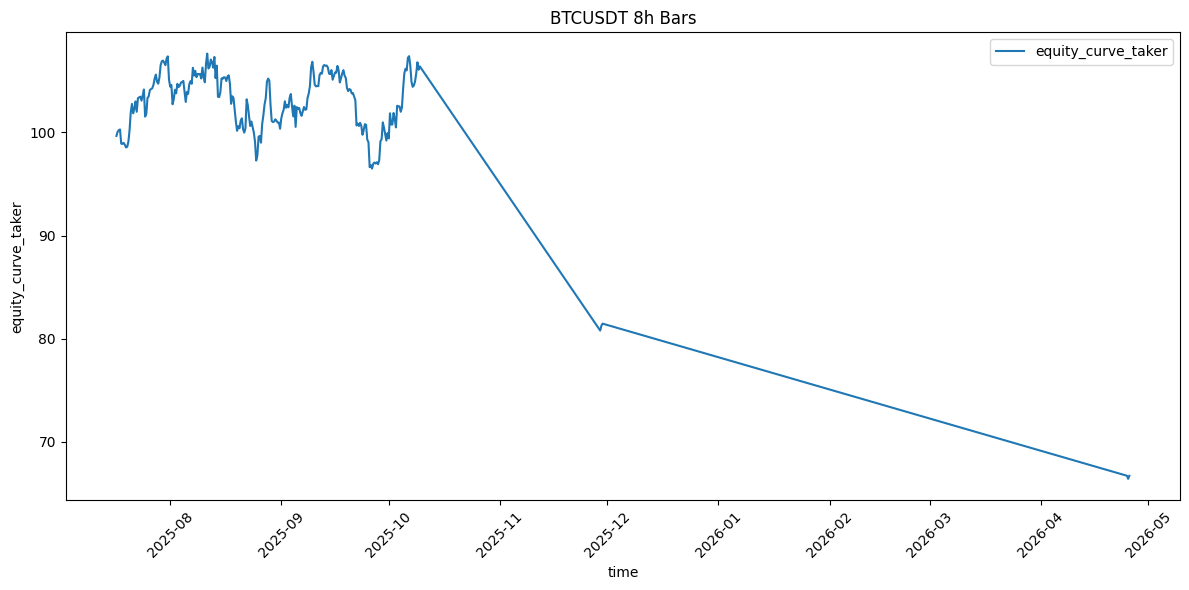

In [66]:
research.plot_static_timeseries(trades, sym, 'equity_curve_taker',time_interval)

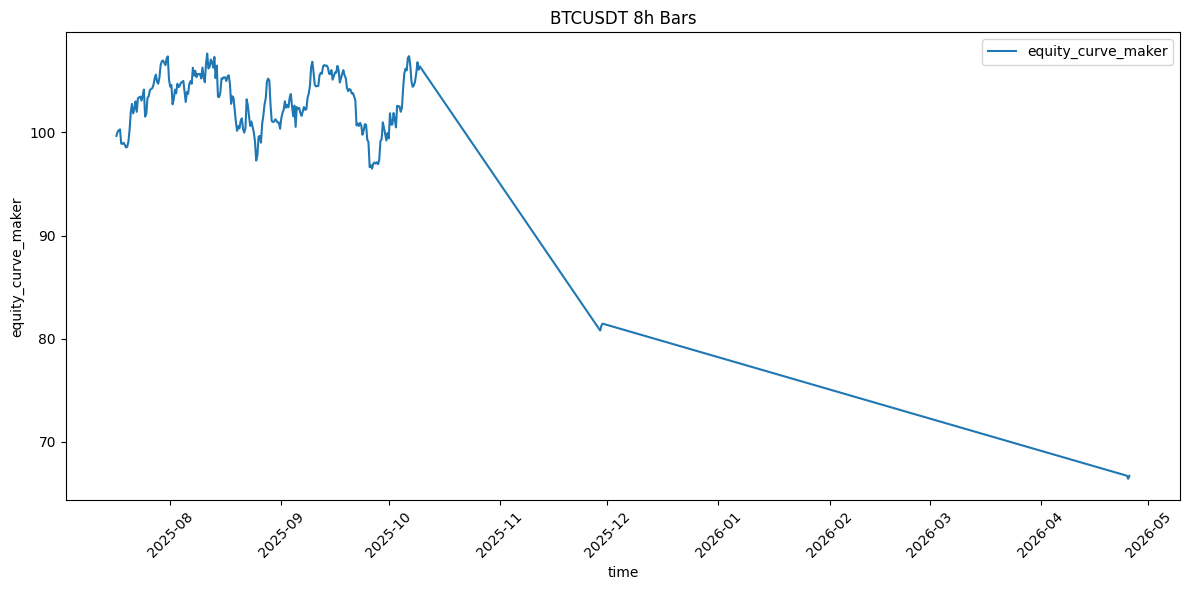

In [67]:
research.plot_static_timeseries(trades, sym, 'equity_curve_maker',time_interval)

### calculate total net return using constant sizing

In [68]:
constant_sizing_net_return = trades['equity_curve_taker'][-1] / capital - 1
constant_sizing_net_return

-0.333029762372678

#### compounding trade sizing

reinvesting earnings basically.

- if you put in 100, and earn two, your next trade you would put in 102
- principle of time additivity

In [69]:
trades = trades.with_columns(
    ((pl.col('cum_trade_log_return').exp()) * capital).shift().fill_null(capital).alias('entry_trade_value'),
    ((pl.col('cum_trade_log_return').exp()) * capital).alias('exit_trade_value')
).with_columns(
    (pl.col('entry_trade_value') / pl.col('open') * pl.col('dir_signal')).alias('signed_trade_qty'),
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl'),
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

datetime,open,close,trade_log_return,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f64,f64,f64,f64
2025-07-17 00:00:00,118590.7,118293.9,-0.002506,100.0,99.749727,0.000843,-0.250273
2025-07-17 08:00:00,118293.8,118875.0,0.0049,99.749727,100.239732,0.000843,0.490005
2025-07-17 16:00:00,118875.0,119176.6,0.002534,100.239732,100.494052,0.000843,0.25432
2025-07-18 00:00:00,119176.5,119356.6,0.001509,100.494052,100.645835,0.000843,0.151783
2025-07-18 08:00:00,119356.5,117830.0,-0.012873,100.645835,99.35855,0.000843,-1.287285
…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91030.0,0.00558,98.850763,99.403856,0.001092,0.553093
2025-11-29 16:00:00,91030.0,90765.0,0.002915,99.403856,99.694078,-0.001092,0.290222
2026-04-25 00:00:00,77395.3,77449.9,-0.158642,99.694078,85.069095,0.001288,-14.624983


##### add transaction fees

In [70]:
trades = research.add_tx_fees(trades, binance.MAKER_FEE, binance.TAKER_FEE)
trades.select('datetime', 'entry_trade_value', 'exit_trade_value', 'tx_fee_maker', 'tx_fee_taker')

datetime,entry_trade_value,exit_trade_value,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64
2025-07-17 00:00:00,100.0,99.749727,0.089887,0.089887
2025-07-17 08:00:00,99.749727,100.239732,0.089995,0.089995
2025-07-17 16:00:00,100.239732,100.494052,0.09033,0.09033
2025-07-18 00:00:00,100.494052,100.645835,0.090513,0.090513
2025-07-18 08:00:00,100.645835,99.35855,0.090002,0.090002
…,…,…,…,…
2025-11-29 08:00:00,98.850763,99.403856,0.089215,0.089215
2025-11-29 16:00:00,99.403856,99.694078,0.089594,0.089594
2026-04-25 00:00:00,99.694078,85.069095,0.083143,0.083143


#### add trade net pnl

In [71]:
trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('tx_fee_taker')).alias('trade_net_taker_pnl')
)

trades.select('datetime', 'open', 'close', 'close_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'trade_gross_pnl', 'trade_net_taker_pnl')

datetime,open,close,close_log_return,y_hat,entry_trade_value,exit_trade_value,trade_gross_pnl,trade_net_taker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64
2025-07-17 00:00:00,118590.7,118293.9,-0.002506,0.000467,100.0,99.749727,-0.250273,-0.34016
2025-07-17 08:00:00,118293.8,118875.0,0.0049,0.000397,99.749727,100.239732,0.490005,0.400009
2025-07-17 16:00:00,118875.0,119176.6,0.002534,0.000033,100.239732,100.494052,0.25432,0.16399
2025-07-18 00:00:00,119176.5,119356.6,0.001509,0.000149,100.494052,100.645835,0.151783,0.06127
2025-07-18 08:00:00,119356.5,117830.0,-0.012873,0.0002,100.645835,99.35855,-1.287285,-1.377287
…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91030.0,0.00558,0.014797,98.850763,99.403856,0.553093,0.463878
2025-11-29 16:00:00,91030.0,90765.0,-0.002915,-7.9431e-7,99.403856,99.694078,0.290222,0.200628
2026-04-25 00:00:00,77395.3,77449.9,-0.158642,0.000417,99.694078,85.069095,-14.624983,-14.708127


### Display equity curve (compounding)

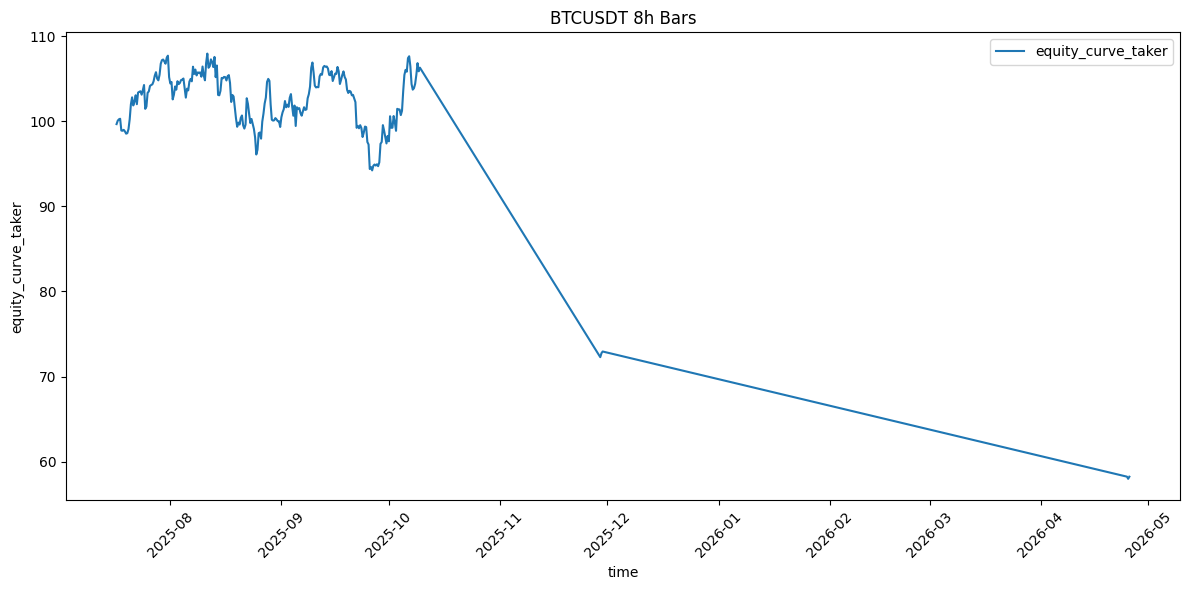

In [72]:
trades = research.add_equity_curve(trades, capital, 'trade_net_taker_pnl', 'taker')
research.plot_static_timeseries(trades, sym, 'equity_curve_taker', time_interval)

### calculate total net return for compounding trade sizing

In [73]:
compound_total_net_return = trades['equity_curve_taker'][-1] / capital - 1
compound_total_net_return

-0.4177437560606784

In [74]:
constant_sizing_net_return

-0.333029762372678

In [75]:
np.round(compound_total_net_return - constant_sizing_net_return, 3)

np.float64(-0.085)

### Strategy decision #3, leverage

borrowing money?


In [76]:
leverage = 4
trades = research.add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-07-17 00:00:00,118590.7,119151.3,117663.6,118293.9,-0.002506,-0.003916,0.007375,0.003753,0.000467,1.0,-0.002506,-0.002506,400.0,398.99891,0.000843,0.003373,-1.00109,0.089887,0.089887,-1.36064,-1.36064,98.63936,98.63936,98.99891,0.35955,0.35955
2025-07-17 08:00:00,118293.8,119216.4,117412.8,118875.0,0.0049,-0.002506,-0.003916,0.007375,0.000397,1.0,0.0049,0.002394,398.99891,400.958928,0.000845,0.003373,1.960019,0.090221,0.090221,1.600038,1.600038,100.239398,100.239398,100.958928,0.359981,0.359981
2025-07-17 16:00:00,118875.0,120951.5,118293.6,119176.6,0.002534,0.0049,-0.002506,-0.003916,0.000033,1.0,0.002534,0.004928,400.958928,401.976209,0.000841,0.003373,1.01728,0.090114,0.090114,0.65596,0.65596,100.895358,100.895358,101.976209,0.361321,0.361321
2025-07-18 00:00:00,119176.5,120846.1,119003.8,119356.6,0.001509,0.002534,0.0049,-0.002506,0.000149,1.0,0.001509,0.006438,401.976209,402.583339,0.000839,0.003373,0.60713,0.090068,0.090068,0.245078,0.245078,101.140436,101.140436,102.583339,0.362052,0.362052
2025-07-18 08:00:00,119356.5,119519.8,117230.7,117830.0,-0.012873,0.001509,0.002534,0.0049,0.0002,1.0,-0.012873,-0.006435,402.583339,397.4342,0.000838,0.003373,-5.149139,0.089424,0.089424,-5.509147,-5.509147,95.631289,95.631289,97.4342,0.360008,0.360008
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91068.1,90335.2,91030.0,0.00558,-0.294957,0.00412,-0.006327,0.014797,1.0,0.00558,-0.005979,395.403052,397.615424,0.001105,0.004368,2.212372,0.090252,0.090252,1.855514,1.855514,-9.04894,-9.04894,97.615424,0.356858,0.356858
2025-11-29 16:00:00,91030.0,91130.0,90092.7,90765.0,-0.002915,0.00558,-0.294957,0.00412,-7.9431e-7,-1.0,0.002915,-0.003064,397.615424,398.776313,0.001099,-0.004368,1.160889,0.090131,0.090131,0.802513,0.802513,-8.246428,-8.246428,98.776313,0.358376,0.358376
2026-04-25 00:00:00,77395.3,77678.0,77254.7,77449.9,-0.158642,-0.002915,0.00558,-0.294957,0.000417,1.0,-0.158642,-0.161706,398.776313,340.276379,0.001292,0.005152,-58.499934,0.083399,0.083399,-58.832507,-58.832507,-67.078935,-67.078935,40.276379,0.332574,0.332574


#### calculate total net return

In [77]:
trades['equity_curve_taker'][-1] / capital -1

-1.6709750242427137

#### increase to 8x leverage? (US legal limit)

In [78]:
leverage = 8
trades = research.add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-07-17 00:00:00,118590.7,119151.3,117663.6,118293.9,-0.002506,-0.003916,0.007375,0.003753,0.000467,1.0,-0.002506,-0.002506,800.0,797.997819,0.000843,0.006746,-2.002181,0.089887,0.089887,-2.72128,-2.72128,97.27872,97.27872,97.997819,0.719099,0.719099
2025-07-17 08:00:00,118293.8,119216.4,117412.8,118875.0,0.0049,-0.002506,-0.003916,0.007375,0.000397,1.0,0.0049,0.002394,797.997819,801.917857,0.000845,0.006746,3.920038,0.090221,0.090221,3.200076,3.200076,100.478796,100.478796,101.917857,0.719962,0.719962
2025-07-17 16:00:00,118875.0,120951.5,118293.6,119176.6,0.002534,0.0049,-0.002506,-0.003916,0.000033,1.0,0.002534,0.004928,801.917857,803.952418,0.000841,0.006746,2.034561,0.090114,0.090114,1.311919,1.311919,101.790715,101.790715,103.952418,0.722642,0.722642
2025-07-18 00:00:00,119176.5,120846.1,119003.8,119356.6,0.001509,0.002534,0.0049,-0.002506,0.000149,1.0,0.001509,0.006438,803.952418,805.166678,0.000839,0.006746,1.21426,0.090068,0.090068,0.490157,0.490157,102.280872,102.280872,105.166678,0.724104,0.724104
2025-07-18 08:00:00,119356.5,119519.8,117230.7,117830.0,-0.012873,0.001509,0.002534,0.0049,0.0002,1.0,-0.012873,-0.006435,805.166678,794.8684,0.000838,0.006746,-10.298278,0.089424,0.089424,-11.018294,-11.018294,91.262578,91.262578,94.8684,0.720016,0.720016
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91068.1,90335.2,91030.0,0.00558,-0.294957,0.00412,-0.006327,0.014797,1.0,0.00558,-0.005979,790.806105,795.230848,0.001105,0.008736,4.424744,0.090252,0.090252,3.711027,3.711027,-118.097881,-118.097881,95.230848,0.713717,0.713717
2025-11-29 16:00:00,91030.0,91130.0,90092.7,90765.0,-0.002915,0.00558,-0.294957,0.00412,-7.9431e-7,-1.0,0.002915,-0.003064,795.230848,797.552626,0.001099,-0.008736,2.321778,0.090131,0.090131,1.605025,1.605025,-116.492855,-116.492855,97.552626,0.716753,0.716753
2026-04-25 00:00:00,77395.3,77678.0,77254.7,77449.9,-0.158642,-0.002915,0.00558,-0.294957,0.000417,1.0,-0.158642,-0.161706,797.552626,680.552759,0.001292,0.010305,-116.999868,0.083399,0.083399,-117.665015,-117.665015,-234.15787,-234.15787,-19.447241,0.665147,0.665147


In [79]:
trades['equity_curve_taker'][-1] / capital -1

-3.3419500484854274

##### wr hasnt changed

In [80]:
trades.select((pl.col('trade_log_return') > 0).mean())

trade_log_return
f64
0.59387


##### basic liquidation model

closing a position

In [81]:
maintenance_margin = 0.005

def long_liquidation_price(p, l, mmr):
    return (p * l) / (l + 1 - mmr * l)

def short_liquidation_price(p, l, mmr):
    return (p * l) / (l - 1 + mmr * 1)

##### show how leverage affects long positions

In [82]:
long_liquidation_price(200, 2, maintenance_margin)

133.7792642140468

In [83]:
long_liquidation_price(200, 4, maintenance_margin)

160.64257028112448

In [84]:
long_liquidation_price(200, 10, maintenance_margin)

182.64840182648402

#### show how leverage affects short positions

In [85]:
short_liquidation_price(200, 2, maintenance_margin)

398.00995024875624

In [86]:
short_liquidation_price(200, 4, maintenance_margin)

266.22296173044924

### add liquidation prices

In [87]:
leverage = 4

In [88]:
trades = trades.with_columns(
    pl.when(pl.col('dir_signal') == 1)
    .then(
        (pl.col('open') * leverage) / (leverage + 1 - maintenance_margin * leverage)
    )
    .when(pl.col('dir_signal') == -1)
    .then(
        (pl.col('open') * leverage) / (leverage - 1 + maintenance_margin * leverage )
    )
    .otherwise(None)
    .alias('liquidation_price')
)

trades.select('datetime', 'open', 'high', 'low', 'close', 'liquidation_price', 'dir_signal')

datetime,open,high,low,close,liquidation_price,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f32
2025-07-17 00:00:00,118590.7,119151.3,117663.6,118293.9,95253.574297,1.0
2025-07-17 08:00:00,118293.8,119216.4,117412.8,118875.0,95015.100402,1.0
2025-07-17 16:00:00,118875.0,120951.5,118293.6,119176.6,95481.927711,1.0
2025-07-18 00:00:00,119176.5,120846.1,119003.8,119356.6,95724.096386,1.0
2025-07-18 08:00:00,119356.5,119519.8,117230.7,117830.0,95868.674699,1.0
…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91068.1,90335.2,91030.0,72709.558233,1.0
2025-11-29 16:00:00,91030.0,91130.0,90092.7,90765.0,120569.536424,-1.0
2026-04-25 00:00:00,77395.3,77678.0,77254.7,77449.9,62164.899598,1.0


### add liquidation flag

In [89]:
trades = trades.with_columns([
    # worst price based on direction
    pl.when(pl.col('dir_signal') == 1)
        .then(pl.col('low'))
        .otherwise(pl.col('high'))
        .alias('worst_price'),
    # liquidation flag
    pl.when(
        (pl.col('dir_signal') == 1) & (pl.col('low') <= pl.col('liquidation_price'))
    )
    .then(True)
    .when(
        (pl.col('dir_signal') == -1) & (pl.col('high') >= pl.col('liquidation_price'))
    )
    .then(True)
    .otherwise(False)
    .alias('liquidated')
])

trades.select('datetime', 'open', 'high', 'low', 'close', 'liquidation_price', 'dir_signal', 'worst_price', 'liquidated')


datetime,open,high,low,close,liquidation_price,dir_signal,worst_price,liquidated
datetime[μs],f64,f64,f64,f64,f64,f32,f64,bool
2025-07-17 00:00:00,118590.7,119151.3,117663.6,118293.9,95253.574297,1.0,117663.6,false
2025-07-17 08:00:00,118293.8,119216.4,117412.8,118875.0,95015.100402,1.0,117412.8,false
2025-07-17 16:00:00,118875.0,120951.5,118293.6,119176.6,95481.927711,1.0,118293.6,false
2025-07-18 00:00:00,119176.5,120846.1,119003.8,119356.6,95724.096386,1.0,119003.8,false
2025-07-18 08:00:00,119356.5,119519.8,117230.7,117830.0,95868.674699,1.0,117230.7,false
…,…,…,…,…,…,…,…,…
2025-11-29 08:00:00,90523.4,91068.1,90335.2,91030.0,72709.558233,1.0,90335.2,false
2025-11-29 16:00:00,91030.0,91130.0,90092.7,90765.0,120569.536424,-1.0,91130.0,false
2026-04-25 00:00:00,77395.3,77678.0,77254.7,77449.9,62164.899598,1.0,77254.7,false


### find liquidated trades

In [90]:
trades.filter(pl.col('liquidated') == True)

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker,liquidation_price,worst_price,liquidated
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
